# 05 — Aligned PPO (Learned Reward)

Train PPO using the learned reward model instead of the environment's reward. Evaluate on the *original* environment (no wrapper) to measure true performance, then compare against the baseline.

In [13]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv
from pathlib import Path

from lunarlander.reward_model import RewardModel
from lunarlander.env_wrappers import LearnedRewardWrapper
from lunarlander.db_logger import ExperimentLogger

CHECKPOINT_DIR = Path('../checkpoints')
DB_PATH = Path('../experiments.db')
REWARD_MODEL_PATH = CHECKPOINT_DIR / 'reward_model.pt'
BASELINE_CKPT = CHECKPOINT_DIR / 'baseline_ppo.zip'

assert REWARD_MODEL_PATH.exists(), f'Run notebook 04 first! Missing {REWARD_MODEL_PATH}'
assert BASELINE_CKPT.exists(), f'Run notebook 01 first! Missing {BASELINE_CKPT}'

DEVICE = 'cpu'
print('Setup complete.')

Setup complete.


In [14]:
# Hyperparameters (same as baseline for fair comparison)
TOTAL_TIMESTEPS = 500_000
N_STEPS = 2048
BATCH_SIZE = 64
N_EPOCHS = 10
LEARNING_RATE = 3e-4
GAMMA = 0.999
GAE_LAMBDA = 0.98
ENT_COEF = 0.01
SEED = 42
N_EVAL_EPISODES = 50

hyperparams = {
    'total_timesteps': TOTAL_TIMESTEPS,
    'n_steps': N_STEPS,
    'batch_size': BATCH_SIZE,
    'n_epochs': N_EPOCHS,
    'learning_rate': LEARNING_RATE,
    'gamma': GAMMA,
    'gae_lambda': GAE_LAMBDA,
    'ent_coef': ENT_COEF,
    'seed': SEED,
    'reward': 'learned (Bradley-Terry MLP)',
}

In [15]:
# Load learned reward model
reward_model = RewardModel.load(REWARD_MODEL_PATH, device=DEVICE)
print(f'Reward model loaded. Feat dim: {reward_model.feat_dim}')

Reward model loaded from ../checkpoints/reward_model.pt
Reward model loaded. Feat dim: 12


In [16]:
# Create wrapped environment (learned reward mixed with env reward during training)
def make_wrapped_env():
    base_env = gym.make('LunarLander-v3')
    wrapped = LearnedRewardWrapper(base_env, reward_model=reward_model, device=DEVICE, scale=0.5)
    return Monitor(wrapped)

train_env = DummyVecEnv([make_wrapped_env])
print('Wrapped training environment created. Reward = env_reward + 0.5 * learned_reward')

Wrapped training environment created. Reward = env_reward + 0.5 * learned_reward


In [17]:
# Train aligned PPO
aligned_model = PPO(
    'MlpPolicy',
    train_env,
    n_steps=N_STEPS,
    batch_size=BATCH_SIZE,
    n_epochs=N_EPOCHS,
    learning_rate=LEARNING_RATE,
    gamma=GAMMA,
    gae_lambda=GAE_LAMBDA,
    ent_coef=ENT_COEF,
    verbose=1,
    seed=SEED,
)

print(f'Training aligned PPO for {TOTAL_TIMESTEPS:,} timesteps...')
aligned_model.learn(total_timesteps=TOTAL_TIMESTEPS, progress_bar=True)
print('Training complete!')

Output()

Using cuda device
Training aligned PPO for 500,000 timesteps...


/home/har5ha/Desktop/LunarLander/.venv/lib/python3.11/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 94.7     |
|    ep_rew_mean     | -234     |
| time/              |          |
|    fps             | 1515     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 90.3        |
|    ep_rew_mean          | -189        |
| time/                   |             |
|    fps                  | 1156        |
|    iterations           | 2           |
|    time_elapsed         | 3           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.011530008 |
|    clip_fraction        | 0.0918      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.38       |
|    explained_variance   | -0.000875   |
|    learning_rate        | 0.0003      |
|    loss                 | 4.21e+03    |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0123     |
|    value_loss           | 9.08e+03    |
-----------------------------------------


...

-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 68.1          |
|    ep_rew_mean          | 418           |
| time/                   |               |
|    fps                  | 963           |
|    iterations           | 242           |
|    time_elapsed         | 514           |
|    total_timesteps      | 495616        |
| train/                  |               |
|    approx_kl            | 0.00022896024 |
|    clip_fraction        | 0.00576       |
|    clip_range           | 0.2           |
|    entropy_loss         | -0.0619       |
|    explained_variance   | 0.981         |
|    learning_rate        | 0.0003        |
|    loss                 | 128           |
|    n_updates            | 2410          |
|    policy_gradient_loss | -0.00232      |
|    value_loss           | 434           |
-------------------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 68.5         |
|    ep_rew_mean          | 419          |
| time/                   |              |
|    fps                  | 963          |
|    iterations           | 243          |
|    time_elapsed         | 516          |
|    total_timesteps      | 497664       |
| train/                  |              |
|    approx_kl            | 0.0004507189 |
|    clip_fraction        | 0.00283      |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.0699      |
|    explained_variance   | 0.98         |
|    learning_rate        | 0.0003       |
|    loss                 | 70.2         |
|    n_updates            | 2420         |
|    policy_gradient_loss | -0.000288    |
|    value_loss           | 287          |
------------------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 67.9         |
|    ep_rew_mean          | 421          |
| time/                   |              |
|    fps                  | 963          |
|    iterations           | 244          |
|    time_elapsed         | 518          |
|    total_timesteps      | 499712       |
| train/                  |              |
|    approx_kl            | 0.0005027478 |
|    clip_fraction        | 0.00195      |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.1         |
|    explained_variance   | 0.905        |
|    learning_rate        | 0.0003       |
|    loss                 | 1.89e+03     |
|    n_updates            | 2430         |
|    policy_gradient_loss | -0.000837    |
|    value_loss           | 2.62e+03     |
------------------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 67.7         |
|    ep_rew_mean          | 423          |
| time/                   |              |
|    fps                  | 963          |
|    iterations           | 245          |
|    time_elapsed         | 520          |
|    total_timesteps      | 501760       |
| train/                  |              |
|    approx_kl            | 0.0001419842 |
|    clip_fraction        | 0.00249      |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.055       |
|    explained_variance   | 0.97         |
|    learning_rate        | 0.0003       |
|    loss                 | 158          |
|    n_updates            | 2440         |
|    policy_gradient_loss | -0.000853    |
|    value_loss           | 447          |
------------------------------------------


Training complete!


In [18]:
# Evaluate on ORIGINAL (unwrapped) environment — true performance measure
def make_raw_env():
    return Monitor(gym.make('LunarLander-v3'))

raw_eval_env = DummyVecEnv([make_raw_env])

aligned_mean, aligned_std = evaluate_policy(
    aligned_model, raw_eval_env, n_eval_episodes=N_EVAL_EPISODES, deterministic=True
)
print(f'Aligned PPO — Mean reward (original env): {aligned_mean:.2f} +/- {aligned_std:.2f}')

Aligned PPO — Mean reward (original env): -553.81 +/- 136.89


In [ ]:
# Compute success/crash rates + fuel efficiency for aligned agent
raw_env = gym.make('LunarLander-v3')
episode_rewards_aligned = []
landed_count = 0
crashed_count = 0
ep_lengths = []
main_engine_counts = []   # fuel efficiency tracking

for _ in range(N_EVAL_EPISODES):
    obs, _ = raw_env.reset()
    ep_reward, ep_len, main_engine_fires = 0.0, 0, 0
    done = False
    while not done:
        action, _ = aligned_model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = raw_env.step(action)
        ep_reward += reward
        ep_len += 1
        if int(action) == 2:       # action 2 = main engine
            main_engine_fires += 1
        done = terminated or truncated
        if terminated:
            if reward == 100:
                landed_count += 1
            elif reward == -100:
                crashed_count += 1
    episode_rewards_aligned.append(ep_reward)
    ep_lengths.append(ep_len)
    main_engine_counts.append(main_engine_fires)

raw_env.close()

aligned_success_rate = landed_count / N_EVAL_EPISODES
aligned_crash_rate   = crashed_count / N_EVAL_EPISODES
aligned_mean_ep_len  = float(np.mean(ep_lengths))
aligned_fuel         = float(np.mean(main_engine_counts))

print(f'Success rate:        {aligned_success_rate:.2%}')
print(f'Crash rate:          {aligned_crash_rate:.2%}')
print(f'Mean episode length: {aligned_mean_ep_len:.1f} steps')
print(f'Mean main-engine fires (fuel): {aligned_fuel:.1f}')

In [20]:
# Save aligned checkpoint
aligned_ckpt_path = CHECKPOINT_DIR / 'aligned_ppo'
aligned_model.save(str(aligned_ckpt_path))
print(f'Checkpoint saved to {aligned_ckpt_path}.zip')

Checkpoint saved to ../checkpoints/aligned_ppo.zip


In [21]:
# Log to SQLite
logger = ExperimentLogger(DB_PATH)
row_id = logger.log(
    name='Aligned PPO — Learned Reward',
    exp_type='aligned_ppo',
    mean_reward=float(aligned_mean),
    std_reward=float(aligned_std),
    success_rate=aligned_success_rate,
    crash_rate=aligned_crash_rate,
    mean_ep_len=aligned_mean_ep_len,
    hyperparams=hyperparams,
    notes=f'PPO trained with Bradley-Terry learned reward. Evaluated on original env ({N_EVAL_EPISODES} eps).',
)
print(f'Logged to SQLite, row id={row_id}')

Logged to SQLite, row id=7


In [ ]:
# Load baseline stats + fuel data
baseline_rows = logger.fetch_by_type('baseline_ppo')
assert baseline_rows, 'No baseline_ppo rows found — run notebook 01 first!'
b = baseline_rows[0]

# Recompute baseline fuel usage for fair comparison
raw_env = gym.make('LunarLander-v3')
baseline_model = PPO.load(str(BASELINE_CKPT))
baseline_fuel_counts = []
for _ in range(N_EVAL_EPISODES):
    obs, _ = raw_env.reset()
    fires, done = 0, False
    while not done:
        action, _ = baseline_model.predict(obs, deterministic=True)
        obs, _, terminated, truncated, _ = raw_env.step(action)
        if int(action) == 2:
            fires += 1
        done = terminated or truncated
    baseline_fuel_counts.append(fires)
raw_env.close()
baseline_fuel = float(np.mean(baseline_fuel_counts))

fuel_saved_pct = (baseline_fuel - aligned_fuel) / baseline_fuel * 100

print('\n========= Baseline vs Aligned PPO — Full Comparison =========')
print(f'{"Metric":<28} {"Baseline":>10} {"Aligned":>10} {"Delta":>10}')
print('─' * 62)
print(f'{"Mean Reward":<28} {b["mean_reward"]:>10.1f} {aligned_mean:>10.1f} {aligned_mean - b["mean_reward"]:>+10.1f}')
print(f'{"Std Reward":<28} {b["std_reward"]:>10.1f} {aligned_std:>10.1f}')
print(f'{"Success Rate":<28} {b["success_rate"]:>10.2%} {aligned_success_rate:>10.2%} {aligned_success_rate - b["success_rate"]:>+10.2%}')
print(f'{"Crash Rate":<28} {b["crash_rate"]:>10.2%} {aligned_crash_rate:>10.2%} {aligned_crash_rate - b["crash_rate"]:>+10.2%}')
print(f'{"Mean Ep Length":<28} {b["mean_ep_len"]:>10.1f} {aligned_mean_ep_len:>10.1f} {aligned_mean_ep_len - b["mean_ep_len"]:>+10.1f}')
print(f'{"Main-Engine Fires (fuel)":<28} {baseline_fuel:>10.1f} {aligned_fuel:>10.1f} {aligned_fuel - baseline_fuel:>+10.1f}')
print('─' * 62)
print(f'  Fuel saved by alignment: {fuel_saved_pct:+.1f}%')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
colors = ['#4C72B0', '#DD8452']

metrics      = ['Mean Reward', 'Success Rate (%)', 'Crash Rate (%)', 'Main-Engine Fires\n(Fuel Use ↓ = Better)']
baseline_vals = [b['mean_reward'], b['success_rate']*100, b['crash_rate']*100, baseline_fuel]
aligned_vals  = [aligned_mean, aligned_success_rate*100, aligned_crash_rate*100, aligned_fuel]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, metric, bval, aval in zip(axes, metrics, baseline_vals, aligned_vals):
    bars = ax.bar(['Baseline\nPPO', 'Aligned\nPPO'], [bval, aval],
                  color=colors, edgecolor='black', alpha=0.88, width=0.5)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    for bar, val in zip(bars, [bval, aval]):
        ypos = bar.get_height() + abs(bar.get_height()) * 0.02 + 0.5
        ax.text(bar.get_x() + bar.get_width()/2, ypos,
                f'{val:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

fig.suptitle('Baseline PPO vs RLHF-Aligned PPO — LunarLander-v3', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../checkpoints/comparison_plot.png', dpi=120, bbox_inches='tight')
plt.show()
print('Comparison plot saved.')

In [ ]:
import imageio
import numpy as np
from PIL import Image, ImageDraw
from IPython.display import Image as IPImage, display

def add_watermark(frames, text="@HAR5HA"):
    """Stamp text onto the white landing pad — bottom centre of each frame."""
    result = []
    for frame in frames:
        img = Image.fromarray(frame)
        draw = ImageDraw.Draw(img)
        w, h = img.size
        # Landing pad sits at bottom-centre ~15% from bottom
        x = w // 2 - 28
        y = int(h * 0.84)
        # Thin dark shadow for contrast on white ground
        draw.text((x + 1, y + 1), text, fill=(80, 80, 80))
        draw.text((x,     y    ), text, fill=(30, 30, 30))
        result.append(np.array(img))
    return result


def record_episode(model, label, env_reward=True):
    env = gym.make('LunarLander-v3', render_mode='rgb_array')
    frames, obs, done = [], env.reset()[0], False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, terminated, truncated, _ = env.step(action)
        frames.append(env.render())
        done = terminated or truncated
    env.close()
    frames = add_watermark(frames)
    path = f'../checkpoints/{label}.gif'
    imageio.mimsave(path, frames, fps=30)
    print(f'{label}: {len(frames)} frames → {path}')
    return path


print('=== Baseline PPO ===')
baseline_gif = record_episode(baseline_model, 'baseline_agent')
display(IPImage(baseline_gif))

print('\n=== Aligned PPO (RLHF) ===')
aligned_gif = record_episode(aligned_model, 'aligned_agent')
display(IPImage(aligned_gif))

=== Baseline PPO ===
baseline_agent: 306 frames → ../checkpoints/baseline_agent.gif


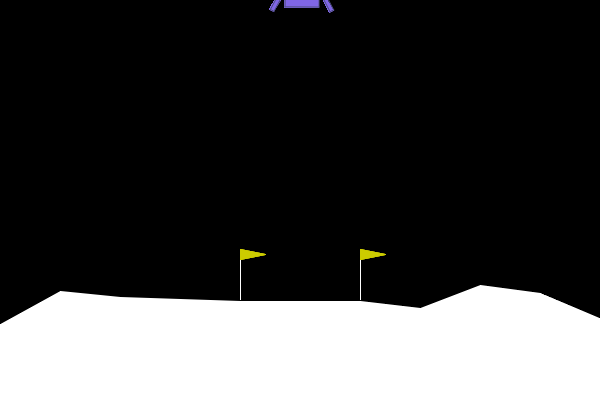


=== Aligned PPO ===
aligned_agent: 69 frames → ../checkpoints/aligned_agent.gif


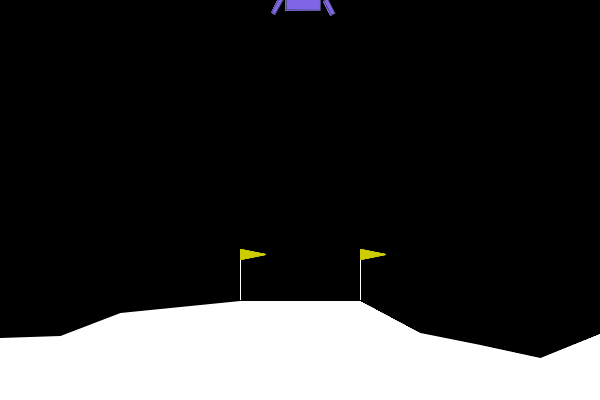

In [25]:
# Record both agents playing side-by-side and display as GIFs
import imageio
from IPython.display import Image as IPImage, display

def record_episode(model, label):
    env = gym.make('LunarLander-v3', render_mode='rgb_array')
    frames = []
    obs, _ = env.reset()
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, terminated, truncated, _ = env.step(action)
        frames.append(env.render())
        done = terminated or truncated
    env.close()
    path = f'../checkpoints/{label}.gif'
    imageio.mimsave(path, frames, fps=30)
    print(f'{label}: {len(frames)} frames → {path}')
    return path

# Load baseline for comparison
baseline_model = PPO.load(str(BASELINE_CKPT))

print('=== Baseline PPO ===')
baseline_gif = record_episode(baseline_model, 'baseline_agent')
display(IPImage(baseline_gif))

print('\n=== Aligned PPO ===')
aligned_gif = record_episode(aligned_model, 'aligned_agent')
display(IPImage(aligned_gif))